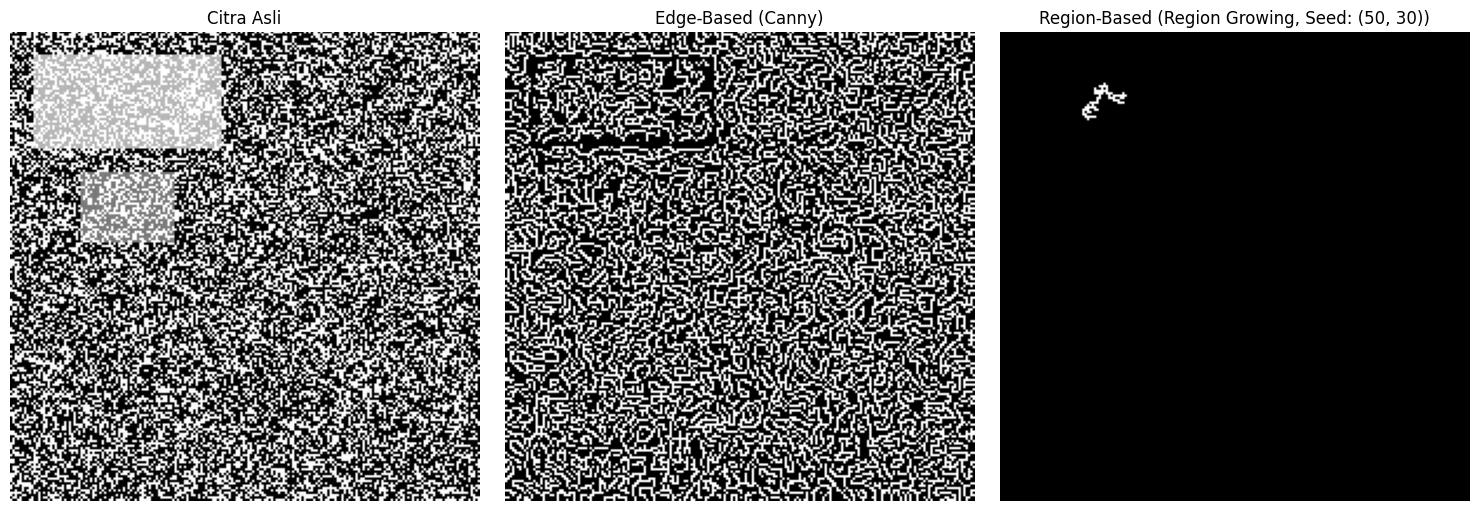

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- 1. Persiapan: Membuat Citra Dummy Sederhana ---

def create_dummy_image(size=(100, 100)):
    """Membuat citra skala abu-abu dengan dua region intensitas."""
    img = np.zeros(size, dtype=np.uint8)

    # Region 1: Area terang (misalnya 180)
    img[10:50, 10:90] = 180

    # Region 2: Area abu-abu (misalnya 120)
    img[60:90, 30:70] = 120

    # Tambahkan sedikit noise Gaussian untuk simulasi dunia nyata
    noise = np.random.normal(0, 5, size).astype(np.uint8)
    img = cv2.add(img, noise)

    return img

# Citra masukan
image = create_dummy_image(size=(200, 200))
image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

# --- 2. Edge-Based Segmentation: Canny Edge Detector ---

def custom_canny_segmentation(img, low_thresh, high_thresh):
    """Menerapkan Canny Edge Detector."""
    # Tahap 1: Noise Reduction (Gaussian Blur)
    blurred = cv2.GaussianBlur(img, (5, 5), 0) # Menggunakan kernel 5x5 untuk mengurangi noise

    # Tahap 2 & 3 & 4: Gradient, Non-maximum Suppression, Hysteresis Thresholding
    edges = cv2.Canny(blurred, low_thresh, high_thresh) # Parameter threshold1 & threshold2 [cite: 135, 137]
    return edges

canny_edges = custom_canny_segmentation(image, low_thresh=30, high_thresh=100)

# --- 3. Region-Based Segmentation: Simple Region Growing ---

def custom_region_growing(image, seed_point, threshold):
    """Implementasi Region Growing sederhana (hanya untuk satu region)."""
    (x, y) = seed_point
    H, W = image.shape

    # Inisialisasi region dan antrian
    region = set([seed_point])
    queue = [seed_point]

    # Intensitas rata-rata (atau referensi) dari region yang tumbuh
    mean_intensity = int(image[y, x]) # Perhatikan urutan (y,x) untuk indexing numpy

    # Kernel untuk tetangga 4-konektivitas
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)] # dx, dy

    # Tumbuhkan region
    while queue:
        (curr_x, curr_y) = queue.pop(0)

        for dx, dy in neighbors:
            nx, ny = curr_x + dx, curr_y + dy

            # Cek batasan citra dan apakah piksel sudah ditambahkan
            if 0 <= nx < W and 0 <= ny < H and (nx, ny) not in region:

                # Kriteria kemiripan: Perbedaan intensitas piksel tetangga
                # dengan intensitas referensi (mean_intensity) harus di bawah threshold
                if abs(int(image[ny, nx]) - mean_intensity) < threshold:
                    region.add((nx, ny))
                    queue.append((nx, ny))

    # Buat citra hasil segmentasi
    segmented_img = np.zeros_like(image, dtype=np.uint8)
    for nx, ny in region:
        segmented_img[ny, nx] = 255

    return segmented_img

# Pilih seed point (misalnya di region terang)
seed_point_1 = (50, 30) # (x, y)
# Terapkan Region Growing
region_grown_img = custom_region_growing(image, seed_point_1, threshold=20)


# --- 4. Visualisasi Hasil ---

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Citra Asli')
axes[0].axis('off')

axes[1].imshow(canny_edges, cmap='gray')
axes[1].set_title('Edge-Based (Canny)')
axes[1].axis('off')

axes[2].imshow(region_grown_img, cmap='gray')
axes[2].set_title(f'Region-Based (Region Growing, Seed: {seed_point_1})')
axes[2].axis('off')

plt.tight_layout()
plt.show()